# 05 — Noise Robustness, Structured Corruption, and Conformal Sensitivity (v2)

This notebook analyzes Step 5 outputs generated from authoritative v2 artifacts.

Outputs expected:

- `noise_robustness_v2.json`
- `feature_sensitivity_v2.json`
- `subject_sensitivity_v2.json`
- `corruption_robustness_v2.json`
- `conformal_v2.json`

In [9]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
ROOT = next((p for p in (cwd, *cwd.parents) if (p / "experiments").exists()), cwd)
RESULTS = ROOT / "experiments" / "results" / "v2"
FIG_PDF = ROOT / "report" / "figures" / "v2" / "pdf"
FIG_PNG = ROOT / "report" / "figures" / "v2" / "png"
TABLES = ROOT / "report" / "tables" / "v2"

for p in (FIG_PDF, FIG_PNG, TABLES):
    p.mkdir(parents=True, exist_ok=True)

CONDITIONS = ("pd", "hd", "als")
CLF_ORDER = ("rf", "knn", "svm", "dt", "qda", "xgb", "lgbm")
SIGMA_LEVELS = (0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.50)
DIRECTIONS = ("pd_to_hd", "hd_to_pd", "pd_to_als", "als_to_pd", "hd_to_als", "als_to_hd")

In [10]:
def loadj(path: Path):
    with open(path) as f:
        return json.load(f)

within = {c: loadj(RESULTS / f"{c}_results_v2.json") for c in CONDITIONS}
cross = loadj(RESULTS / "cross_condition_results_v2.json")
noise = loadj(RESULTS / "noise_robustness_v2.json")
feat = loadj(RESULTS / "feature_sensitivity_v2.json")
subj = loadj(RESULTS / "subject_sensitivity_v2.json")
corr = loadj(RESULTS / "corruption_robustness_v2.json")
conf = loadj(RESULTS / "conformal_v2.json")

rows = []
for cond in CONDITIONS:
    for clf in CLF_ORDER:
        f1_ref = float(within[cond]["classifiers"][clf]["f1_macro"])
        f1_noise0 = float(np.mean(noise["within"][cond][clf]["0.0"]))
        rows.append({"scope": f"within:{cond}", "clf": clf, "f1_ref": f1_ref, "f1_noise0": f1_noise0, "abs_diff": abs(f1_ref - f1_noise0)})
for dkey, dr in cross.items():
    for clf in CLF_ORDER:
        if clf not in dr["classifiers"] or clf not in noise["cross"].get(dkey, {}):
            continue
        f1_ref = float(dr["classifiers"][clf]["f1_macro"])
        f1_noise0 = float(np.mean(noise["cross"][dkey][clf]["0.0"]))
        rows.append({"scope": f"cross:{dkey}", "clf": clf, "f1_ref": f1_ref, "f1_noise0": f1_noise0, "abs_diff": abs(f1_ref - f1_noise0)})

verify_df = pd.DataFrame(rows)
verify_df.sort_values(["scope", "clf"]).head(20)

,scope,clf,f1_ref,f1_noise0,abs_diff
17,within:als,dt,0.690098,0.756174,0.066076
15,within:als,knn,0.829963,0.818955,0.011008
20,within:als,lgbm,0.751959,0.734387,0.017572
18,within:als,qda,0.820878,0.820878,0.000000
14,within:als,rf,0.740073,0.750090,0.010017
16,within:als,svm,0.709767,0.749321,0.039554
19,within:als,xgb,0.714802,0.822641,0.107839
10,within:hd,dt,0.905270,0.905270,0.000000
8,within:hd,knn,0.804574,0.810429,0.005855
13,within:hd,lgbm,0.862585,0.862585,0.000000


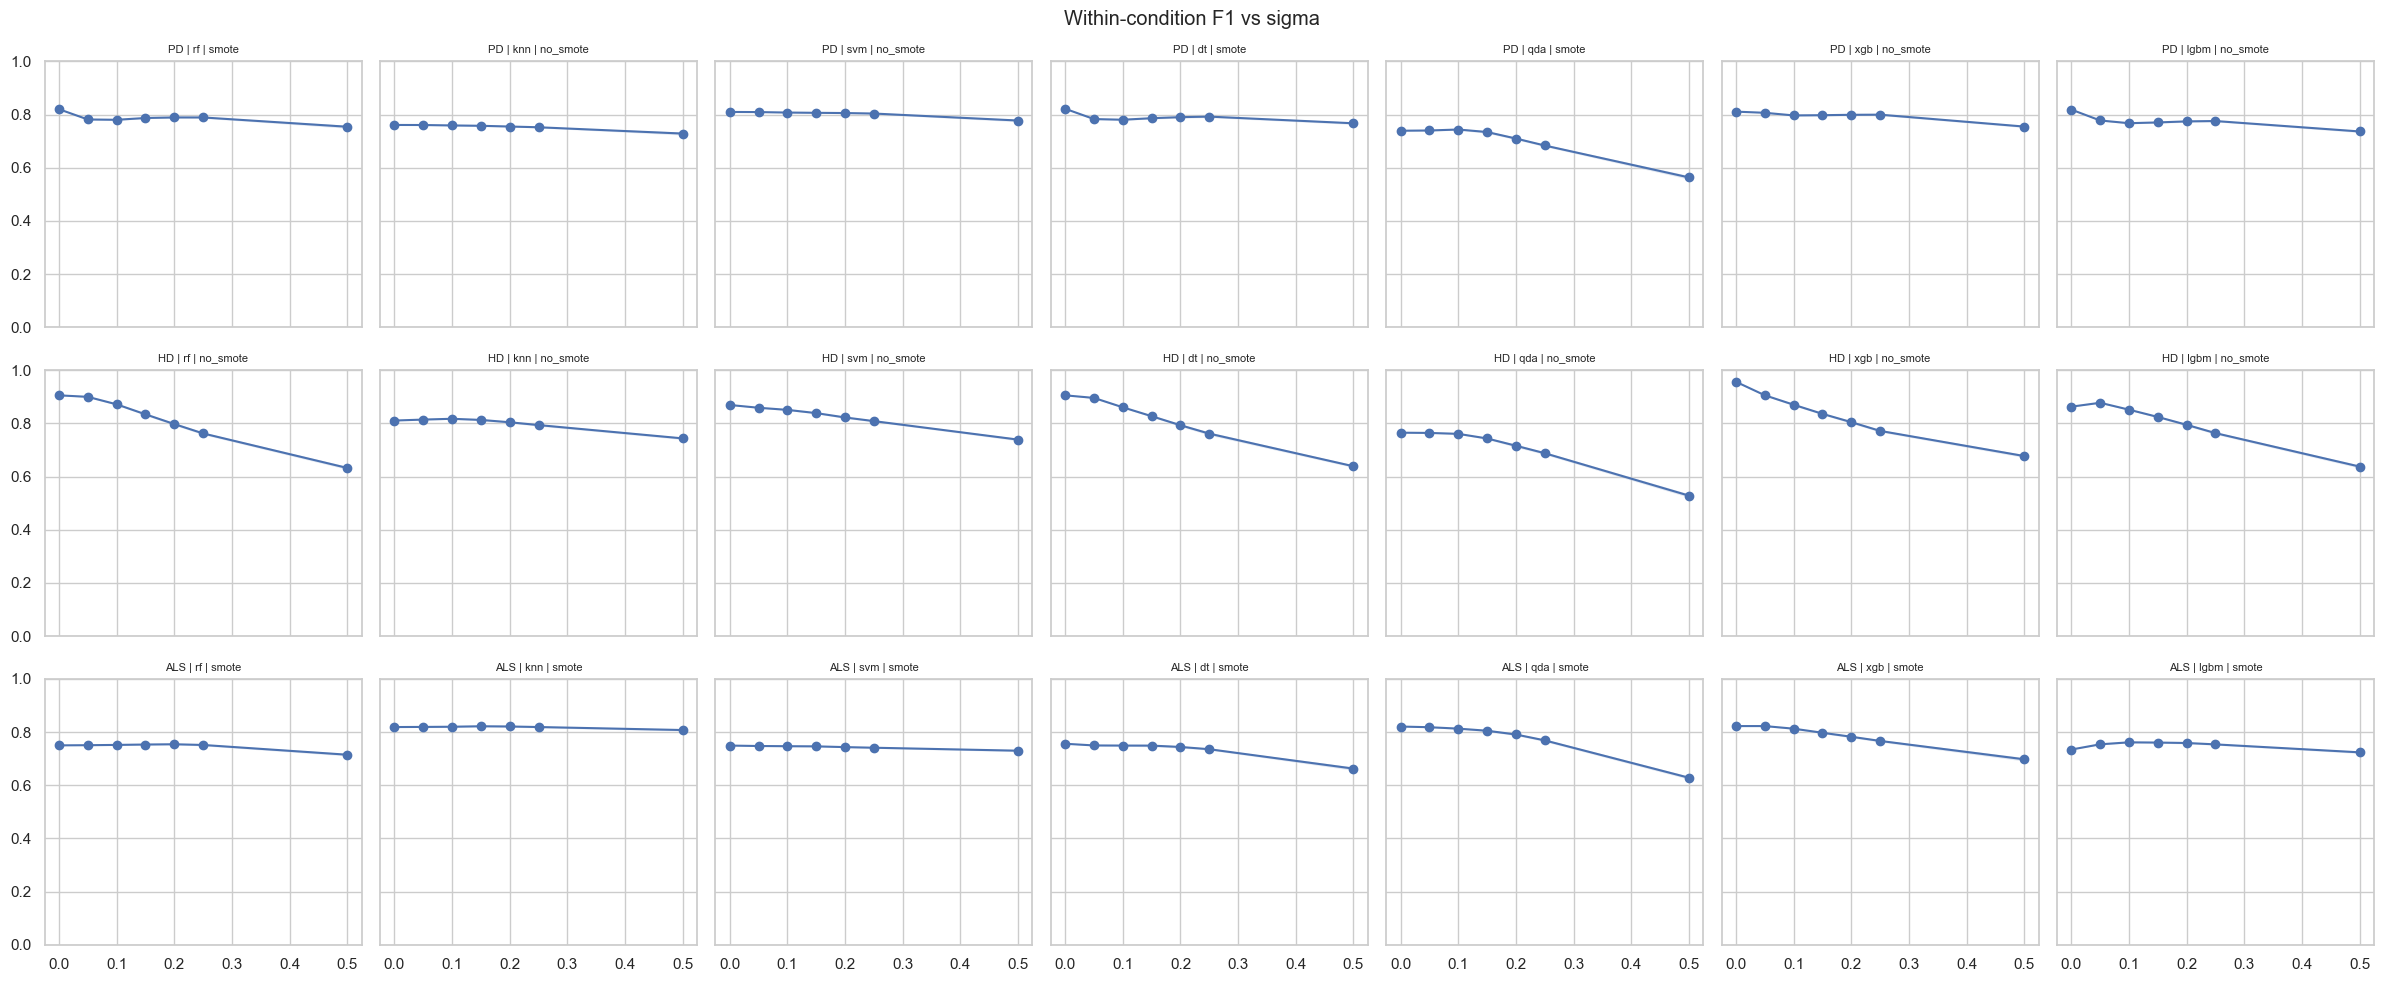

In [11]:
# Fig 5.1 within noise curves
fig, axes = plt.subplots(3, 7, figsize=(24, 10), sharex=True, sharey=True)
for i, cond in enumerate(CONDITIONS):
    for j, clf in enumerate(CLF_ORDER):
        ax = axes[i, j]
        d = noise["within"][cond][clf]
        xs = [float(s) for s in d.keys()]
        ys = [float(np.mean(d[str(x)] if str(x) in d else d[f"{x:g}"])) for x in xs]
        es = [float(np.std(d[str(x)] if str(x) in d else d[f"{x:g}"])) for x in xs]
        ax.plot(xs, ys, marker="o", linewidth=1.5)
        ax.fill_between(xs, np.array(ys)-np.array(es), np.array(ys)+np.array(es), alpha=0.2)
        smote = within[cond]["classifiers"][clf].get("selected_resampling", "smote")
        ax.set_title(f"{cond.upper()} | {clf} | {smote}", fontsize=8)
        ax.set_ylim(0, 1)
fig.suptitle("Within-condition F1 vs sigma")
plt.tight_layout()
fig.savefig(FIG_PDF / "noise_curves_within.pdf", bbox_inches="tight")
fig.savefig(FIG_PNG / "noise_curves_within.png", dpi=250, bbox_inches="tight")
plt.show()

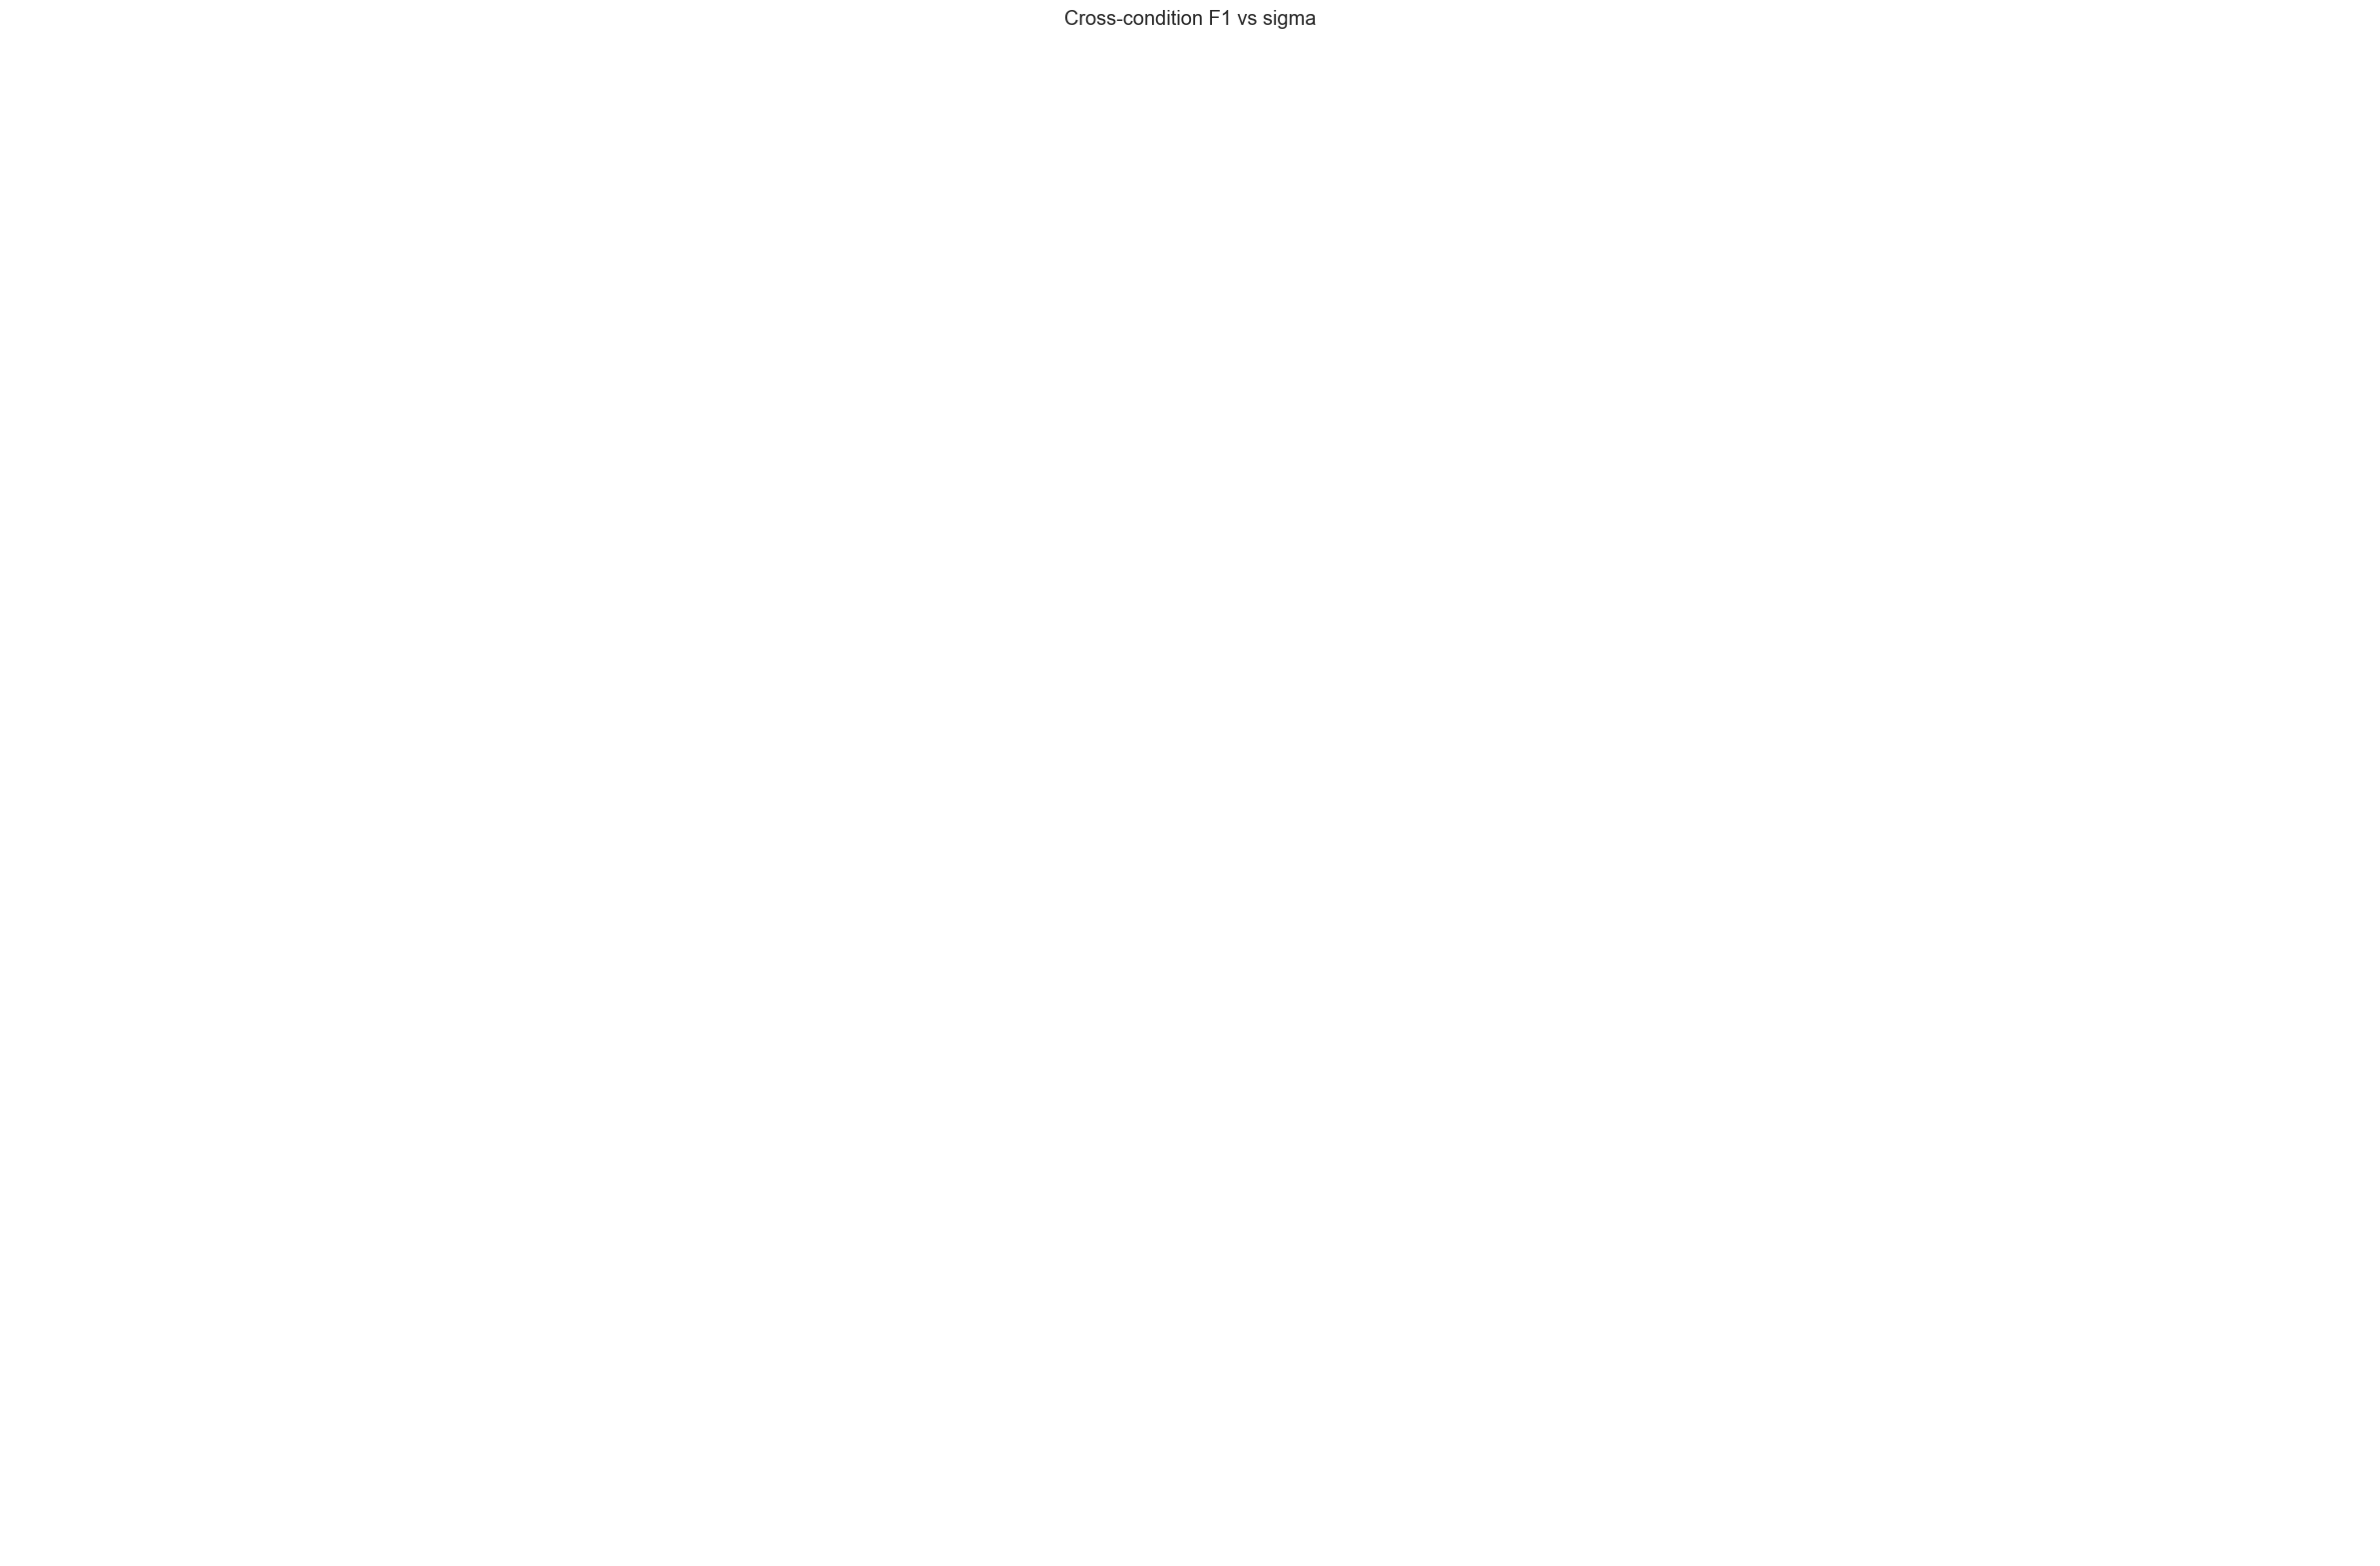

In [12]:
# Fig 5.2 cross noise curves
fig, axes = plt.subplots(6, 7, figsize=(24, 16), sharex=True, sharey=True)
for i, dkey in enumerate(DIRECTIONS):
    for j, clf in enumerate(CLF_ORDER):
        ax = axes[i, j]
        d = noise["cross"].get(dkey, {}).get(clf)
        if not d:
            ax.axis("off")
            continue
        xs = [float(s) for s in d.keys()]
        ys = [float(np.mean(d[str(x)] if str(x) in d else d[f"{x:g}"])) for x in xs]
        es = [float(np.std(d[str(x)] if str(x) in d else d[f"{x:g}"])) for x in xs]
        ax.plot(xs, ys, marker="o", linewidth=1.2)
        ax.fill_between(xs, np.array(ys)-np.array(es), np.array(ys)+np.array(es), alpha=0.2)
        ax.set_title(f"{dkey} | {clf}", fontsize=7)
        ax.set_ylim(0, 1)
fig.suptitle("Cross-condition F1 vs sigma")
plt.tight_layout()
fig.savefig(FIG_PDF / "noise_curves_cross.pdf", bbox_inches="tight")
fig.savefig(FIG_PNG / "noise_curves_cross.png", dpi=250, bbox_inches="tight")
plt.show()

In [13]:
# Table 5.1 robustness summary
rows = []
for cond in CONDITIONS:
    for clf in CLF_ORDER:
        d = noise["within"][cond][clf]
        getm = lambda s: float(np.mean(d[str(s)] if str(s) in d else d[f"{s:g}"]))
        f0, f10, f25, f50 = getm(0.0), getm(0.10), getm(0.25), getm(0.50)
        threshold = 0.9 * f0
        sigma_drop = next((s for s in SIGMA_LEVELS if getm(s) <= threshold), None)
        rows.append({"scope": f"within:{cond}", "clf": clf, "f1@0": f0, "f1@0.10": f10, "f1@0.25": f25, "f1@0.50": f50, "delta_f1_at_0.25": f0-f25, "sigma_at_10pct_drop": sigma_drop})
for dkey in DIRECTIONS:
    for clf in CLF_ORDER:
        d = noise["cross"].get(dkey, {}).get(clf)
        if not d:
            continue
        getm = lambda s: float(np.mean(d[str(s)] if str(s) in d else d[f"{s:g}"]))
        f0, f10, f25, f50 = getm(0.0), getm(0.10), getm(0.25), getm(0.50)
        threshold = 0.9 * f0
        sigma_drop = next((s for s in SIGMA_LEVELS if getm(s) <= threshold), None)
        rows.append({"scope": f"cross:{dkey}", "clf": clf, "f1@0": f0, "f1@0.10": f10, "f1@0.25": f25, "f1@0.50": f50, "delta_f1_at_0.25": f0-f25, "sigma_at_10pct_drop": sigma_drop})
summary_df = pd.DataFrame(rows)
summary_df.to_csv(TABLES / "noise_robustness_summary.csv", index=False)
summary_df.head(20)

,scope,clf,f1@0,f1@0.10,f1@0.25,f1@0.50,delta_f1_at_0.25,sigma_at_10pct_drop
0,within:pd,rf,0.820142,0.780314,0.789130,0.754220,0.031012,NaN
1,within:pd,knn,0.760883,0.759092,0.752231,0.728537,0.008652,NaN
2,within:pd,svm,0.809795,0.807552,0.803858,0.777553,0.005937,NaN
3,within:pd,dt,0.821787,0.780541,0.792282,0.767179,0.029505,NaN
4,within:pd,qda,0.739148,0.743755,0.683629,0.563708,0.055519,0.50
5,within:pd,xgb,0.810980,0.796765,0.799609,0.754839,0.011371,NaN
6,within:pd,lgbm,0.818610,0.767503,0.775651,0.736460,0.042959,0.50
7,within:hd,rf,0.905270,0.871446,0.762013,0.632192,0.143257,0.20
8,within:hd,knn,0.810429,0.817105,0.793444,0.743400,0.016985,NaN
9,within:hd,svm,0.868997,0.850601,0.808303,0.738778,0.060694,0.50


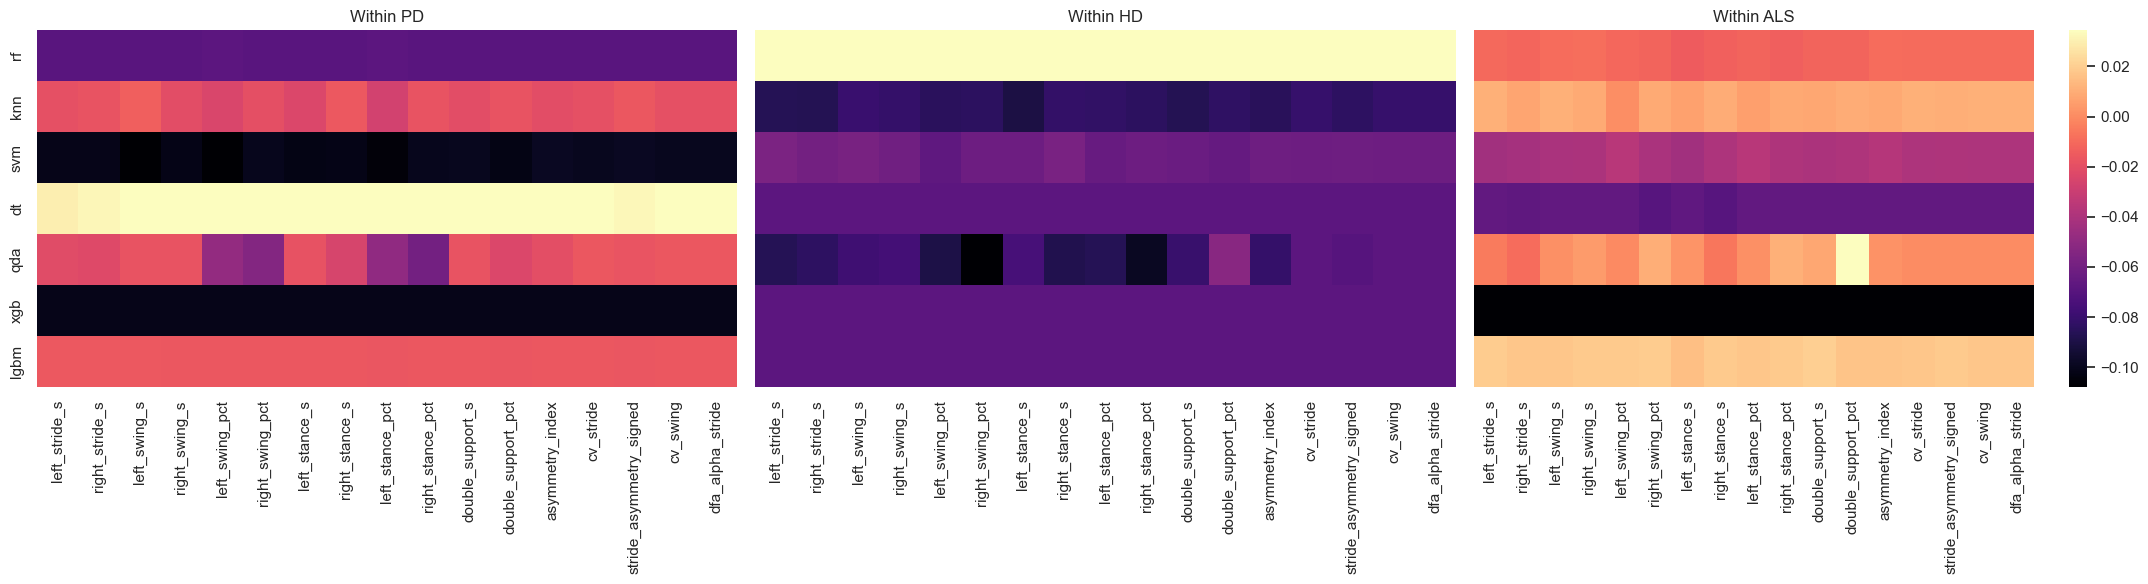

KeyError: "None of [Index(['left_stride_s', 'right_stride_s', 'left_swing_s', 'right_swing_s',\n       'left_swing_pct', 'right_swing_pct', 'left_stance_s', 'right_stance_s',\n       'left_stance_pct', 'right_stance_pct', 'double_support_s',\n       'double_support_pct', 'asymmetry_index', 'cv_stride',\n       'stride_asymmetry_signed', 'cv_swing', 'dfa_alpha_stride'],\n      dtype='object')] are in the [columns]"

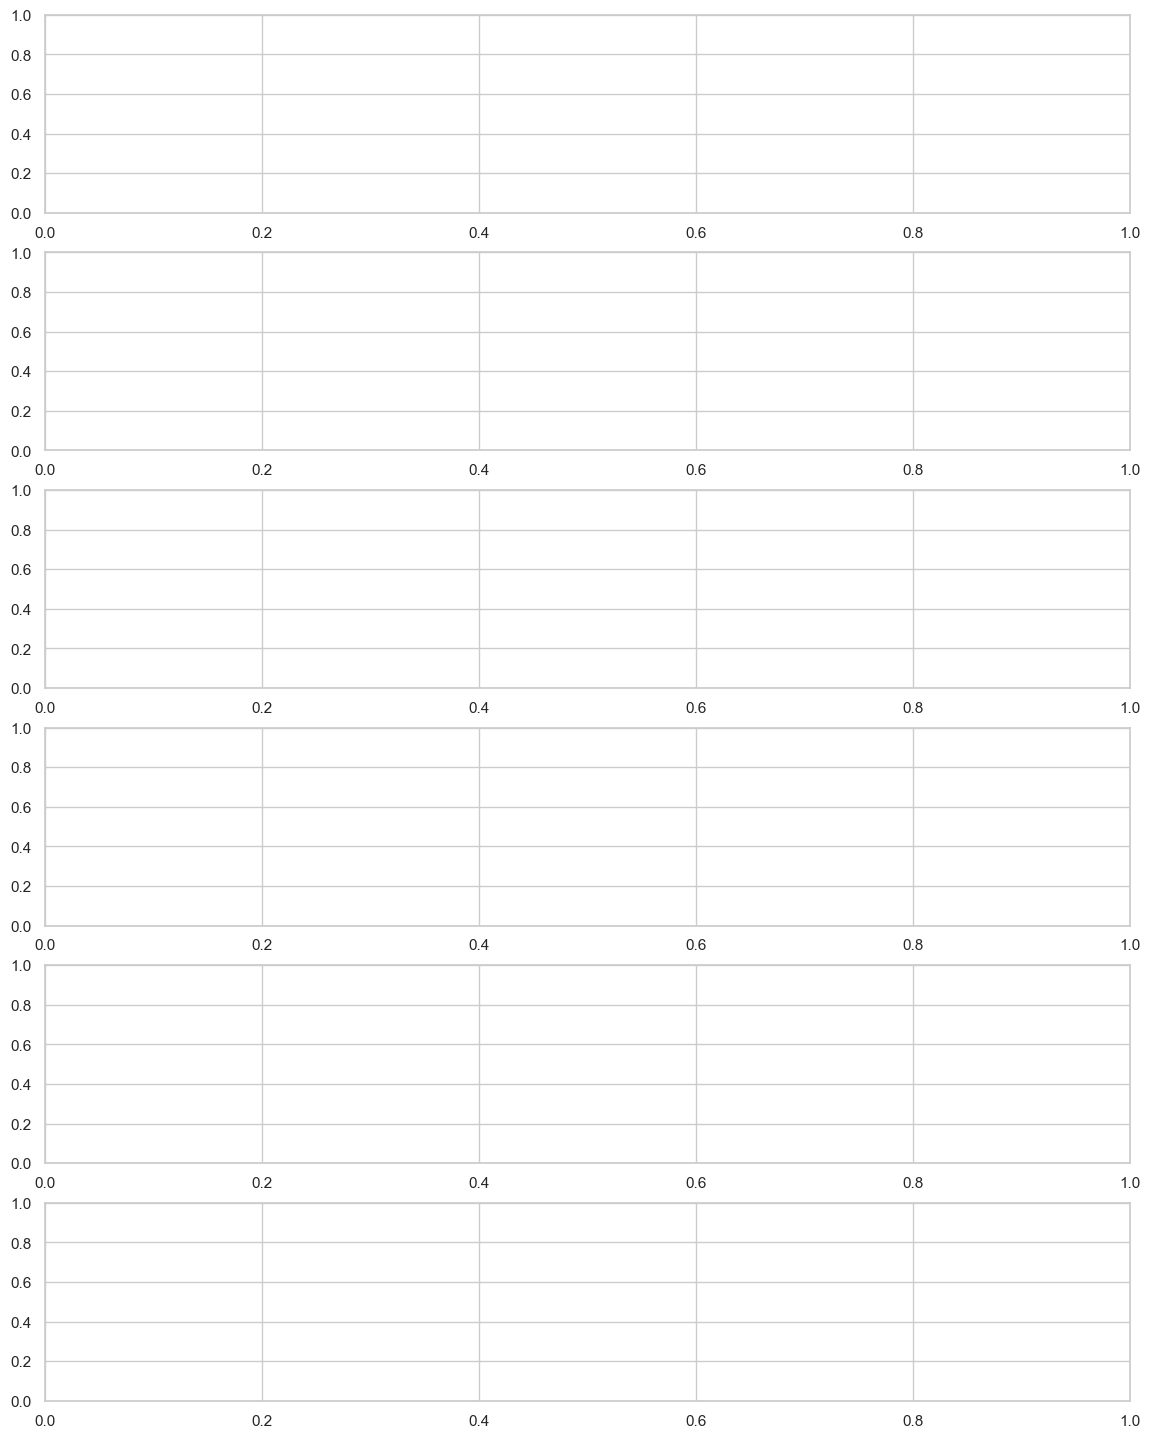

In [14]:
# Fig 5.3 feature sensitivity heatmaps + top3 table
features = list(next(iter(feat["within"]["pd"].values())).keys())

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for i, cond in enumerate(CONDITIONS):
    mat = pd.DataFrame(feat["within"][cond]).T
    cols = [f for f in features if f in mat.columns]
    if cols:
        mat = mat[cols]
        sns.heatmap(mat, ax=axes[i], cmap="magma", cbar=i == 2)
    else:
        axes[i].text(0.5, 0.5, "No matching features", ha="center", va="center")
    axes[i].set_title(f"Within {cond.upper()}")
fig.tight_layout()
fig.savefig(FIG_PDF / "feature_sensitivity_within.pdf", bbox_inches="tight")
fig.savefig(FIG_PNG / "feature_sensitivity_within.png", dpi=250, bbox_inches="tight")
plt.show()

cross_keys = [k for k in DIRECTIONS if k in feat["cross"]]
cross_nonempty = [k for k in cross_keys if feat["cross"].get(k)]
if cross_nonempty:
    fig, axes = plt.subplots(len(cross_nonempty), 1, figsize=(14, 3 * max(1, len(cross_nonempty))))
    if len(cross_nonempty) == 1:
        axes = [axes]
    for i, dkey in enumerate(cross_nonempty):
        mat = pd.DataFrame(feat["cross"][dkey]).T
        cols = [f for f in features if f in mat.columns]
        if cols:
            mat = mat[cols]
            sns.heatmap(mat, ax=axes[i], cmap="magma")
        else:
            axes[i].text(0.5, 0.5, "No matching features", ha="center", va="center")
        axes[i].set_title(f"Cross {dkey}")
    fig.tight_layout()
    fig.savefig(FIG_PDF / "feature_sensitivity_cross.pdf", bbox_inches="tight")
    fig.savefig(FIG_PNG / "feature_sensitivity_cross.png", dpi=250, bbox_inches="tight")
    plt.show()
else:
    print("No non-empty cross feature-sensitivity entries found; skipping cross heatmap.")

top_rows = []
for dkey in cross_nonempty:
    for clf in CLF_ORDER:
        if clf not in feat["cross"][dkey]:
            continue
        s = pd.Series(feat["cross"][dkey][clf]).sort_values(ascending=False).head(3)
        for rank, (fname, drop) in enumerate(s.items(), start=1):
            top_rows.append({"direction": dkey, "clf": clf, "rank": rank, "feature": fname, "delta_f1_drop": drop})

top3 = pd.DataFrame(top_rows)
top3.to_csv(TABLES / "feature_sensitivity_top3.csv", index=False)
top3.head(20)



In [ ]:
# Fig 5.4 per-subject accuracy plots
rows_within = []
for cond in CONDITIONS:
    for clf in CLF_ORDER:
        for sid, rec in subj["within"][cond][clf].items():
            rows_within.append({"scope": cond, "clf": clf, "subject_id": sid, "accuracy": rec["accuracy"], "n_strides": rec["n_strides"]})
within_subj_df = pd.DataFrame(rows_within)

plt.figure(figsize=(20, 6))
sns.boxplot(data=within_subj_df, x="clf", y="accuracy", hue="scope")
plt.ylim(0, 1)
plt.title("Within per-subject accuracy")
plt.tight_layout()
plt.savefig(FIG_PDF / "subject_sensitivity_within.pdf", bbox_inches="tight")
plt.savefig(FIG_PNG / "subject_sensitivity_within.png", dpi=250, bbox_inches="tight")
plt.show()

rows_cross = []
for dkey in DIRECTIONS:
    if dkey not in subj["cross"]:
        continue
    for clf in CLF_ORDER:
        if clf not in subj["cross"][dkey]:
            continue
        for sid, rec in subj["cross"][dkey][clf].items():
            rows_cross.append({"scope": dkey, "clf": clf, "subject_id": sid, "accuracy": rec["accuracy"], "n_strides": rec["n_strides"]})
cross_subj_df = pd.DataFrame(rows_cross)

plt.figure(figsize=(24, 6))
sns.boxplot(data=cross_subj_df, x="clf", y="accuracy", hue="scope")
plt.ylim(0, 1)
plt.title("Cross per-subject accuracy")
plt.tight_layout()
plt.savefig(FIG_PDF / "subject_sensitivity_cross.pdf", bbox_inches="tight")
plt.savefig(FIG_PNG / "subject_sensitivity_cross.png", dpi=250, bbox_inches="tight")
plt.show()

worst3_within = within_subj_df.sort_values("accuracy").groupby(["scope", "clf"]).head(3)
worst3_within.head(20)

In [ ]:
# Fig 5.5 structured corruption + summary table
sev_order = ["light", "medium", "heavy"]
cor_types = list(corr["within"]["pd"].keys())

def corr_delta_matrix(block):
    rows = []
    for ctype in cor_types:
        for sev in sev_order:
            for clf in CLF_ORDER:
                vals = block.get(ctype, {}).get(sev, {}).get(clf, [])
                rows.append({"corruption": ctype, "severity": sev, "clf": clf, "delta": float(np.mean(vals)) if vals else np.nan})
    df = pd.DataFrame(rows)
    return df

within_corr_rows = []
for cond in CONDITIONS:
    dfc = corr_delta_matrix(corr["within"][cond])
    dfc["scope"] = f"within:{cond}"
    within_corr_rows.append(dfc)
within_corr_df = pd.concat(within_corr_rows, ignore_index=True)
within_corr_df.to_csv(TABLES / "corruption_robustness_summary.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
for i, cond in enumerate(CONDITIONS):
    part = within_corr_df[within_corr_df["scope"] == f"within:{cond}"]
    piv = part.pivot_table(index=["corruption", "severity"], columns="clf", values="delta")
    if piv.empty or piv.shape[0] == 0 or piv.shape[1] == 0 or not np.isfinite(piv.to_numpy(dtype=float)).any():
        axes[i].text(0.5, 0.5, "No corruption data", ha="center", va="center")
    else:
        sns.heatmap(piv, ax=axes[i], cmap="viridis", cbar=i == 2)
    axes[i].set_title(f"Within {cond.upper()} corruption")
fig.tight_layout()
fig.savefig(FIG_PDF / "corruption_within.pdf", bbox_inches="tight")
fig.savefig(FIG_PNG / "corruption_within.png", dpi=250, bbox_inches="tight")
plt.show()

cross_corr_rows = []
for dkey in DIRECTIONS:
    if dkey not in corr["cross"]:
        continue
    dfc = corr_delta_matrix(corr["cross"][dkey])
    dfc["scope"] = f"cross:{dkey}"
    cross_corr_rows.append(dfc)
if cross_corr_rows:
    cross_corr_df = pd.concat(cross_corr_rows, ignore_index=True)
    fig, ax = plt.subplots(figsize=(14, 8))
    p = cross_corr_df.groupby(["scope", "corruption", "severity"], as_index=False)["delta"].mean()
    heat = p.pivot_table(index=["scope", "corruption"], columns="severity", values="delta")
    if heat.empty or heat.shape[0] == 0 or heat.shape[1] == 0 or not np.isfinite(heat.to_numpy(dtype=float)).any():
        ax.text(0.5, 0.5, "No cross-corruption data", ha="center", va="center")
    else:
        sns.heatmap(heat, ax=ax, cmap="viridis")
    ax.set_title("Cross corruption mean macro-F1")
    fig.tight_layout()
    fig.savefig(FIG_PDF / "corruption_cross.pdf", bbox_inches="tight")
    fig.savefig(FIG_PNG / "corruption_cross.png", dpi=250, bbox_inches="tight")
    plt.show()



In [ ]:
# Fig 5.6 + 5.7 conformal coverage / set size / aggregation

def conformal_rows(block, scope_name):
    rows = []
    for clf, methods in block.items():
        for method, alpha_map in methods.items():
            for alpha, rec in alpha_map.items():
                rows.append({
                    "scope": scope_name,
                    "clf": clf,
                    "method": method,
                    "alpha": float(alpha),
                    "nominal": 1.0 - float(alpha),
                    "coverage": rec["coverage_marginal"],
                    "mean_set_size": rec["mean_set_size"],
                })
    return rows

rows_conf = []
for cond in CONDITIONS:
    rows_conf.extend(conformal_rows(conf["within"][cond], f"within:{cond}"))
for dkey in DIRECTIONS:
    if dkey in conf["cross"]:
        rows_conf.extend(conformal_rows(conf["cross"][dkey], f"cross:{dkey}"))

conf_df = pd.DataFrame(rows_conf)
conf_df.to_csv(TABLES / "conformal_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
within_conf = conf_df[conf_df["scope"].str.startswith("within:")]
sns.lineplot(data=within_conf, x="nominal", y="coverage", hue="scope", style="method", markers=True, ax=axes[0])
axes[0].plot([0.7, 1.0], [0.7, 1.0], "k--", linewidth=1)
axes[0].set_title("Within conformal coverage vs nominal")
sns.lineplot(data=within_conf, x="alpha", y="mean_set_size", hue="scope", style="method", markers=True, ax=axes[1])
axes[1].set_title("Within mean prediction-set size")
fig.tight_layout()
fig.savefig(FIG_PDF / "conformal_within.pdf", bbox_inches="tight")
fig.savefig(FIG_PNG / "conformal_within.png", dpi=250, bbox_inches="tight")
plt.show()

cross_conf = conf_df[conf_df["scope"].str.startswith("cross:")]
if not cross_conf.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.lineplot(data=cross_conf, x="nominal", y="coverage", hue="scope", style="method", markers=False, ax=axes[0])
    axes[0].plot([0.7, 1.0], [0.7, 1.0], "k--", linewidth=1)
    axes[0].set_title("Cross conformal coverage vs nominal")
    sns.lineplot(data=cross_conf, x="alpha", y="mean_set_size", hue="scope", style="method", markers=False, ax=axes[1])
    axes[1].set_title("Cross mean prediction-set size")
    fig.tight_layout()
    fig.savefig(FIG_PDF / "conformal_cross.pdf", bbox_inches="tight")
    fig.savefig(FIG_PNG / "conformal_cross.png", dpi=250, bbox_inches="tight")
    plt.show()

# Aggregation curves from within entries (lac, alpha=0.1)
agg_rows = []
for cond in CONDITIONS:
    for clf in CLF_ORDER:
        rec = conf["within"][cond][clf]["lac"].get("0.1") or conf["within"][cond][clf]["lac"].get("0.10")
        if not rec:
            continue
        for n, p in rec["stride_aggregation_curve"].items():
            agg_rows.append({"scope": cond, "clf": clf, "n": int(n), "singleton_rate": float(p)})
agg_df = pd.DataFrame(agg_rows)

plt.figure(figsize=(14, 6))
sns.lineplot(data=agg_df, x="n", y="singleton_rate", hue="scope", style="clf", markers=False)
plt.ylim(0, 1)
plt.title("Conformal aggregation curve (LAC, alpha=0.10)")
plt.tight_layout()
plt.savefig(FIG_PDF / "conformal_aggregation.pdf", bbox_inches="tight")
plt.savefig(FIG_PNG / "conformal_aggregation.png", dpi=250, bbox_inches="tight")
plt.show()

## Discussion prompts (update after execution)

- Which classifiers are most sigma-fragile per condition, and does HD no-SMOTE selection change degradation slope?
- Which of `stride_asymmetry_signed`, `cv_swing`, `dfa_alpha_stride` has the largest permutation drop in within and cross settings?
- Which transfer directions have the steepest sigma and structured-corruption degradation?
- Which subjects are persistently low-accuracy across classifiers?
- Which corruption type dominates each cohort relative to Gaussian sigma=0.25?
- What conformal operating point (alpha, required stride count) gives acceptable coverage and singleton rate?